In [49]:
# importar bibliotecas
import geopandas as gpd
import matplotlib.pyplot as plt

In [50]:
# Ler os dados com geopandas
data = gpd.read_file('..\data\MG_Municipios_2024.shp')

In [51]:
# Ver os primeiros dados
data.head(5)

,CD_MUN,NM_MUN,CD_RGI,NM_RGI,CD_RGINT,NM_RGINT,CD_UF,NM_UF,SIGLA_UF,CD_REGIA,NM_REGIA,SIGLA_RG,CD_CONCU,NM_CONCU,AREA_KM2,geometry
0,3104106,Arceburgo,310044,Guaxupé,3108,Varginha,31,Minas Gerais,MG,3,Sudeste,SE,NaN,NaN,162.875,"POLYGON ((-46.96283 -21.41951, -46.96371 -21.4..."
1,3112802,Capitólio,310049,Piumhi,3108,Varginha,31,Minas Gerais,MG,3,Sudeste,SE,NaN,NaN,521.802,"POLYGON ((-45.98629 -20.61341, -45.9863 -20.61..."
2,3120870,Curral de Dentro,310008,Salinas,3102,Montes Claros,31,Minas Gerais,MG,3,Sudeste,SE,NaN,NaN,570.950,"POLYGON ((-41.8656 -15.8367, -41.8656 -15.8367..."
3,3117207,Conceição das Pedras,310052,Itajubá,3109,Pouso Alegre,31,Minas Gerais,MG,3,Sudeste,SE,NaN,NaN,102.206,"POLYGON ((-45.43629 -22.12177, -45.4361 -22.12..."
4,3156403,Romaria,310061,Monte Carmelo,3111,Uberlândia,31,Minas Gerais,MG,3,Sudeste,SE,NaN,NaN,407.557,"POLYGON ((-47.66483 -18.92924, -47.66476 -18.9..."


<Axes: >

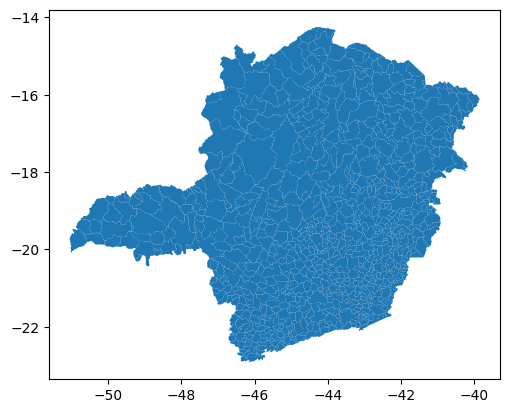

In [52]:
data.plot()

In [53]:
# Filtrar somente BH
gdf_bh = data[data['NM_MUN'] == 'Belo Horizonte']
gdf_bh

,CD_MUN,NM_MUN,CD_RGI,NM_RGI,CD_RGINT,NM_RGINT,CD_UF,NM_UF,SIGLA_UF,CD_REGIA,NM_REGIA,SIGLA_RG,CD_CONCU,NM_CONCU,AREA_KM2,geometry
148,3106200,Belo Horizonte,310001,Belo Horizonte,3101,Belo Horizonte,31,Minas Gerais,MG,3,Sudeste,SE,3106200,Belo Horizonte/MG,331.354,"POLYGON ((-43.86937 -19.92441, -43.86937 -19.9..."


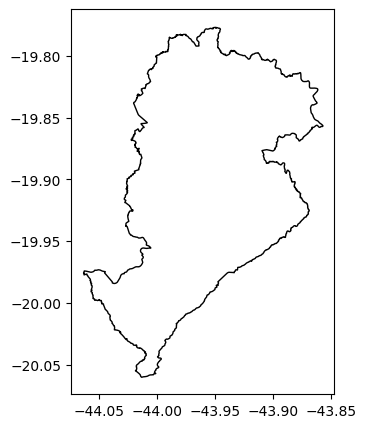

In [54]:
# Mostrar geometria de BH
gdf_bh.plot(figsize=(5, 5), facecolor="white", edgecolor="black")
plt.show()

In [55]:
# Salvar somente o municipio em GeoJSON
filename = "..\data\capital_Belo_Horizonte.json"
gdf_bh.to_file(filename,driver="GeoJSON")

In [56]:
# Ler o arquivo salvo somente da capital
gdf_bh = gpd.read_file(filename, driver="GeoJSON")
gdf_bh

c:\Users\Ricardo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: driver GeoJSON does not support open option DRIVER
  return ogr_read(


,CD_MUN,NM_MUN,CD_RGI,NM_RGI,CD_RGINT,NM_RGINT,CD_UF,NM_UF,SIGLA_UF,CD_REGIA,NM_REGIA,SIGLA_RG,CD_CONCU,NM_CONCU,AREA_KM2,geometry
0,3106200,Belo Horizonte,310001,Belo Horizonte,3101,Belo Horizonte,31,Minas Gerais,MG,3,Sudeste,SE,3106200,Belo Horizonte/MG,331.354,"POLYGON ((-43.86937 -19.92441, -43.86937 -19.9..."


##### vvvv Objetos Geométricos vvvv

In [57]:
# Importar objetos
from shapely.geometry import Point, LineString, Polygon

**Ponto**: Pontos de interesse no mapa, localização, ocorrência de um evento. Recebe coordenadas X e Y.

In [58]:
# Criar geometria basica
ponto = Point(5, 10)
print(ponto)

POINT (5 10)


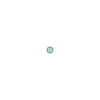

In [59]:
# Visualizar ponto no notebook
ponto

In [60]:
# Ler coordenadas
list(ponto.coords)

[(5.0, 10.0)]

In [61]:
# Ler X e Y separados
x = ponto.x
y = ponto.y

print(x , y)

5.0 10.0


In [62]:
# Calcular distância entre dois pontos
ponto_1 = Point(2, 3)
ponto_2 = Point(6, 7)

distancia = ponto_1.distance(ponto_2)
print("distancia: ", distancia)

distancia:  5.656854249492381


**LineString**L: Pontos conectados por segmentos de reta. Trajetórias, Caminhos e Fronteiras

In [63]:
# Criar linha a partir de pontos
ponto_1 = Point(2, 3)
ponto_2 = Point(4, 6)
ponto_3 = Point (5, 4)

linha = LineString([ponto_1, ponto_2, ponto_3])

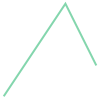

In [64]:
# Visualizar linha na interface
linha

In [65]:
print(linha)

LINESTRING (2 3, 4 6, 5 4)


In [66]:
type(linha)

shapely.geometry.linestring.LineString

In [67]:
# coordenadas
list(linha.coords)

[(2.0, 3.0), (4.0, 6.0), (5.0, 4.0)]

In [68]:
# Separar Xs e Ys
print(linha.xy)

coords_x = list(linha.xy[0])
coords_y = list(linha.xy[1])

print("coordenadas A: ", coords_x)
print("coordenadas Y: ", coords_y)

(array('d', [2.0, 4.0, 5.0]), array('d', [3.0, 6.0, 4.0]))
coordenadas A:  [2.0, 4.0, 5.0]
coordenadas Y:  [3.0, 6.0, 4.0]


In [69]:
# comprimento da linha
linha.length

5.841619252963779

In [70]:
# centróide da linha (retorna um ponto)
print(linha.centroid)

POINT (3.574173327805978 4.691391109268659)


**Polígono**: Conjunto de pelo menos 3 pontos conectados por segmentos de reta em que o último ponto é conectado ao primeiro. Divisões administrativas, Acidentes dgeográficos, edifícios, etc. Recebe pelo menos 3 coordenadas. Pode ter um buraco no meio, que exiger novas coordenadas.

In [71]:
# criar um polígono com coordenadas
poly = Polygon([(2,3),(6,7),(2,10)])

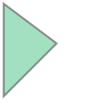

In [72]:
poly

In [73]:
print(poly)

POLYGON ((2 3, 6 7, 2 10, 2 3))


In [74]:
# Obter coordenadas do polígono
list(poly.exterior.coords)
# primeiro ponto = ultimo ponto

[(2.0, 3.0), (6.0, 7.0), (2.0, 10.0), (2.0, 3.0)]

In [75]:
poly_area = poly.area
poly_centroid = poly.centroid
# bounding box é o menor retângulo alinhado aos eixos que envolve completamente um polígono
# .bounds retorna (minx, miny, maxx, maxy),
poly_bounds = poly.bounds 

print("area = ", poly_area)
print("centroid = ", poly_centroid)
print("bounds = ", poly.bounds)

area =  14.0
centroid =  POINT (3.333333333333333 6.666666666666666)
bounds =  (2.0, 3.0, 6.0, 10.0)


In [76]:
# coordenadas das linhas exteriores
poly_exterior = poly.exterior
print(poly_exterior)

LINEARRING (2 3, 6 7, 2 10, 2 3)


In [77]:
# Perímetro
print(poly_exterior.length)

17.65685424949238


Operações entre geometrias:

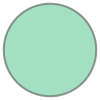

In [78]:
# criar círculos 
circulo_1 = Point(1, 1).buffer(1) # buffer cresce igualmente todas as extremidades
circulo_2 = Point(2, 1).buffer(1)

circulo_2

In [79]:
type(circulo_2) # na verdade é um polígono!

shapely.geometry.polygon.Polygon

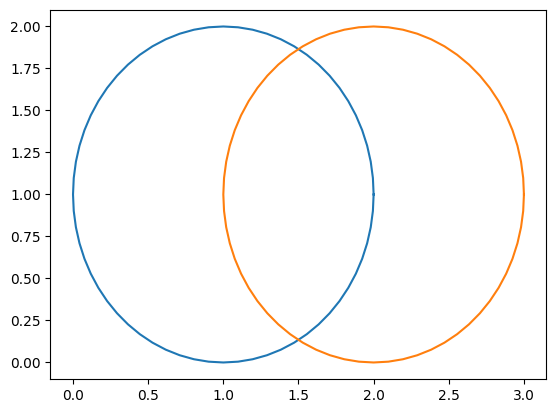

In [80]:
# plotar circulo_1
x, y = circulo_1.exterior.xy
plt.plot(x, y)

# plotar circulo_2
x, y = circulo_2.exterior.xy
plt.plot(x, y)

plt.show()

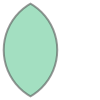

In [81]:
# operação de interseção
intersection = circulo_1.intersection(circulo_2)
intersection

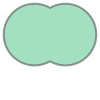

In [82]:
# união
union = circulo_1.union(circulo_2)
union

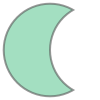

In [83]:
# diferença
diferenca = circulo_1.difference(circulo_2)
diferenca
# é

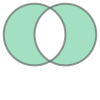

In [84]:
# diferença simétrica

diff_sym = circulo_1.symmetric_difference(circulo_2)
diff_sym

#### vvvvv Tratamento dos Dados vvvvv

In [85]:
# importar 
import pandas as pd
import geopandas as gpd
from shapely import wkt
import matplotlib.pyplot as plt

In [86]:
def carregar_logradouros_bh(caminho_csv):
    # Carrega o CSV
    df = pd.read_csv(caminho_csv, sep=',')
    
    # Converte a coluna de texto para geometria real
    df['geometry'] = df['GEOMETRIA'].apply(wkt.loads)
    
    # Transforma em GeoDataFrame definindo o sistema UTM de BH (EPSG 31983)
    gdf_logradouros = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:31983")
    
    return gdf_logradouros

def carregar_eqpEsportivo(caminho_csv):
    # Carrega o CSV
    df = pd.read_csv(caminho_csv, sep=';')
    
    # Converte a coluna de texto para geometria real
    df['geometry'] = df['GEOMETRIA'].apply(wkt.loads)
    
    # Transforma em GeoDataFrame definindo o sistema UTM de BH (EPSG 31983)
    gdf_eqpEsportivo = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:31983")
    
    return gdf_eqpEsportivo


In [87]:
def exibir_logradouros(gdf_logradouros):
    # Exibe apenas as linhas (ruas) do CSV
    gdf_logradouros.plot(figsize=(10, 10), color='blue')
    plt.title("Geometrias dos Logradouros (Apenas CSV)")
    plt.show()

def exibir_sobre_mapa_bh(gdf_logradouros, gdf_bh):
    # Garantir que o mapa de BH esteja no mesmo sistema UTM das ruas
    gdf_bh_projetado = gdf_bh.to_crs(gdf_logradouros.crs)
    
    # Plotagem em camadas
    fig, ax = plt.subplots(figsize=(12, 12))
    
    # Camada de baixo: O perímetro de BH
    gdf_bh_projetado.plot(ax=ax, color='lightgrey', edgecolor='white')
    
    # Camada de cima: Os logradouros
    gdf_logradouros.plot(ax=ax, color='red', linewidth=0.3)
    
    plt.title("Logradouros sobre o Perímetro de Belo Horizonte")
    plt.show()

In [88]:
def exibir_eqpEsportivo_sobre_bh(gdf_pontos, gdf_bh):
    # Garante a mesma projeção
    gdf_bh_projetado = gdf_bh.to_crs(gdf_pontos.crs)
    
    fig, ax = plt.subplots(figsize=(12, 12))
    
    # Camada 1: O mapa de fundo de BH
    gdf_bh_projetado.plot(ax=ax, color='#f2f2f2', edgecolor='#bcbcbc')
    
    # Camada 2: Os pontos esportivos
    # markersize: controla o tamanho do ponto
    # alpha: transparência (útil se houver pontos sobrepostos)
    gdf_pontos.plot(ax=ax, 
                    color='green', 
                    markersize=6, 
                    marker='o', 
                    alpha=0.7, 
                    label='Equipamentos Esportivos')
    
    plt.title("Distribuição de Equipamentos Esportivos em BH")
    plt.legend()
    plt.show()

In [89]:
# Carregando os logradouros e eqpEsportivos
logradouros = carregar_logradouros_bh('..\data\Logradouros_BH.csv')
eqpEsportivo = carregar_eqpEsportivo('..\data\equipamento_esportivo.csv')

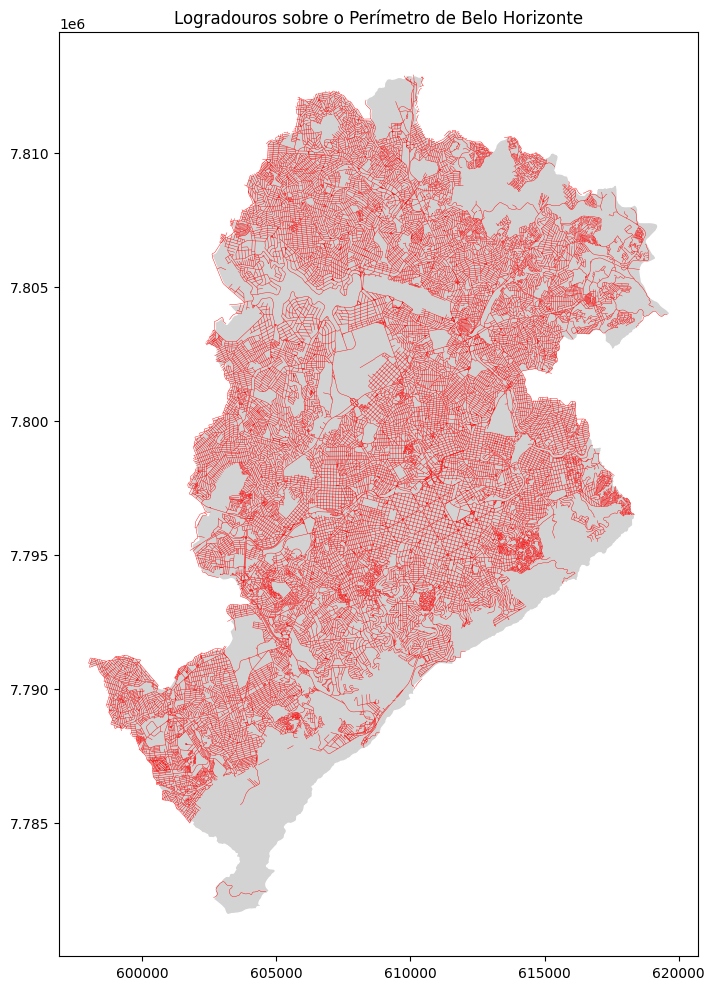

In [90]:
exibir_sobre_mapa_bh(logradouros, gdf_bh)

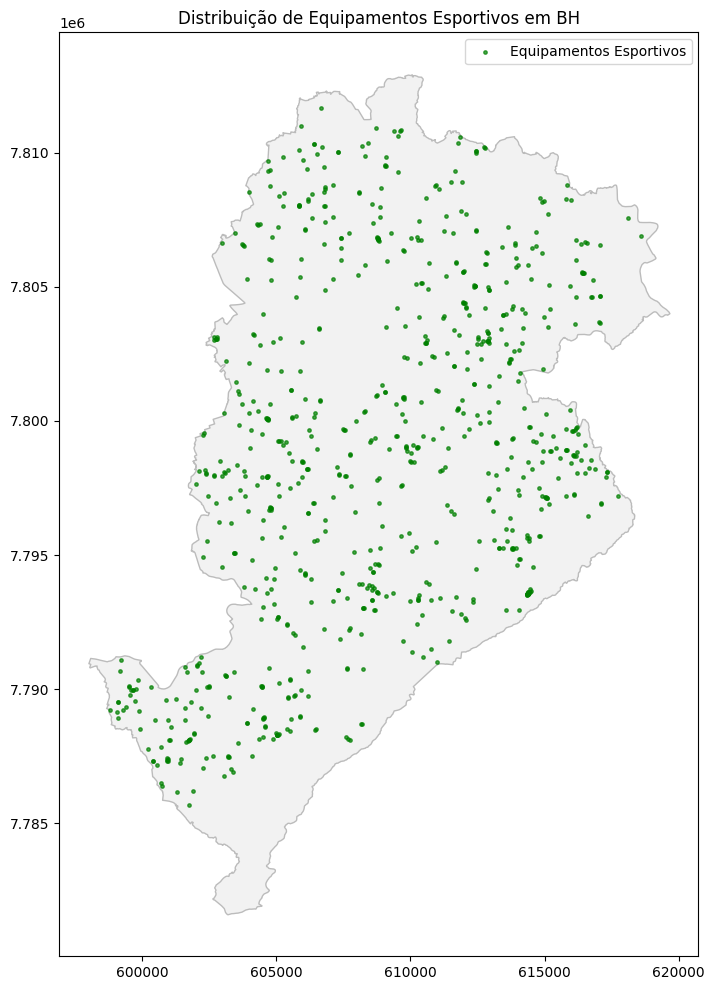

In [91]:
exibir_eqpEsportivo_sobre_bh(eqpEsportivo, gdf_bh)

In [92]:
filename = "..\data\eqpEsportivo_bh.json"
eqpEsportivo.to_file(filename,driver="GeoJSON")

<Axes: >

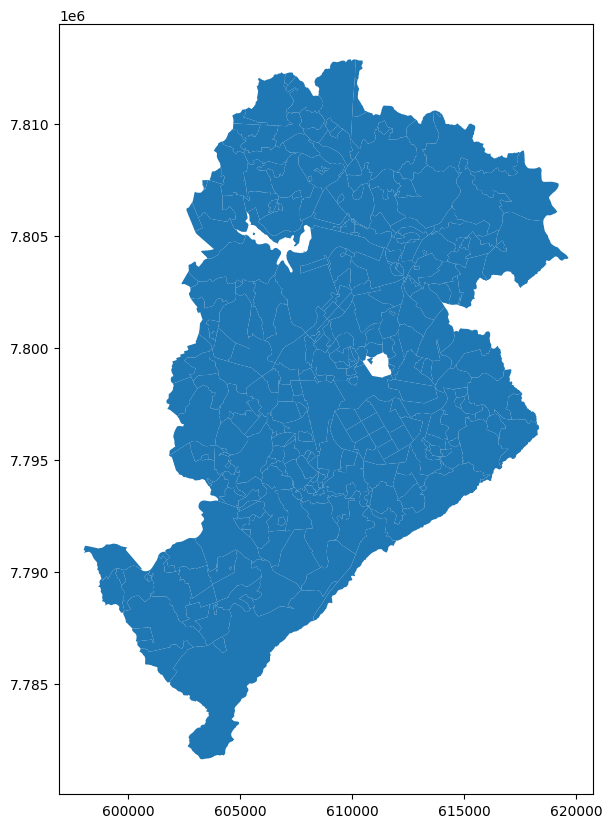

In [93]:
df = pd.read_csv("../data/bairros_bh.csv", sep=',')
df['geometry'] = df['GEOMETRIA'].apply(wkt.loads)
gdf_bairros = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:31983")

gdf_bairros.plot(figsize=(10, 10))

In [94]:
filename = "../data/bairros_bh.json"
gdf_bairros.to_file(filename,driver="GeoJSON")